***QUESTION 3***: _To what extent can multiple datasets (flood damage, housing prices, and geographic variation) be used together to understand the broader consequences of environmental shocks, even in the absence of perfectly aligned data structures?_


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [17]:
flood = pd.read_csv("Post-Katrina_Damage_Assessment.csv")

print("Flood columns:")
print(flood.columns.tolist())

print("\nFlood head:")
print(flood.head())

/var/folders/v_/crprn84x4z3fglfytz4l1s9m0000gn/T/ipykernel_28519/2323582647.py:1: DtypeWarning: Columns (0: FloodZone, 1: Add6, 2: Add7, 3: Add8, 4: Add9, 5: Add10, 6: Add11, 7: Add12, 8: Add17, 9: Add18) have mixed types. Specify dtype option on import or set low_memory=False.
  flood = pd.read_csv("Post-Katrina_Damage_Assessment.csv")


Flood columns:
['Address', 'Percentage', 'Foundations_Basements', 'Superstructure_Framing_Masonry', 'Roofing', 'InsulationandWeatherStripping', 'ExteriorFinish', 'InteriorFinish_Plaster_Drywall', 'Doors_Windows_Shutters', 'LumberFinished', 'Hardware', 'Cabinets_Countertops', 'Floor_Covering', 'Plumbing', 'Electrical', 'Builtin_Appliances', 'Heating_Cooling', 'Painting', 'Foundations_Basements_DamagePer', 'Superstructure_Framing_Masonry_DamagePer', 'Roofing_DamagePer', 'InsulationandWeatherStripping_DamagePer', 'ExteriorFinish_DamagePer', 'InteriorFinish_Plaster_Drywall_DamagePer', 'Doors_Windows_Shutters_DamagePer', 'LumberFinished_DamagePer', 'Hardware_DamagePer', 'Cabinets_Countertops_DamagePer', 'Floor_Covering_DamagePer', 'Plumbing_DamagePer', 'Electrical_DamagePer', 'Builtin_Appliances_DamagePer', 'Heating_Cooling_DamagePer', 'Painting_DamagePer', 'FloodDepth', 'FloodDuration', 'FloodZone', 'PropertyDescription', 'Owner', 'TaxBill', 'Add1', 'Add2', 'Add3', 'Add4', 'Add5', 'Add6', 

In [18]:
hpi_state = pd.read_csv("hpi_at_state.csv", header=None)
hpi_state.columns = ['state', 'year', 'quarter', 'hpi']

hpi_state['year'] = pd.to_numeric(hpi_state['year'], errors='coerce')
hpi_state['quarter'] = pd.to_numeric(hpi_state['quarter'], errors='coerce')
hpi_state['hpi'] = pd.to_numeric(hpi_state['hpi'], errors='coerce')

hpi_state = hpi_state.dropna()

gulf_states = ['LA', 'MS', 'AL']
hpi_gulf = hpi_state[hpi_state['state'].isin(gulf_states)].copy()

annual_hpi = (
    hpi_gulf.groupby(['state', 'year'], as_index=False)['hpi']
    .mean()
    .sort_values(['state', 'year'])
)

print("annual_hpi columns:")
print(annual_hpi.columns.tolist())

print("\nannual_hpi head:")
print(annual_hpi.head())

annual_hpi columns:
['state', 'year', 'hpi']

annual_hpi head:
  state  year       hpi
0    AL  1975   73.2925
1    AL  1976   76.8775
2    AL  1977   85.4650
3    AL  1978   92.4500
4    AL  1979  102.1025


In [19]:
flood = pd.read_csv("Post-Katrina_Damage_Assessment.csv")
print(flood.columns)
print(flood.head())

Index(['Address', 'Percentage', 'Foundations_Basements',
       'Superstructure_Framing_Masonry', 'Roofing',
       'InsulationandWeatherStripping', 'ExteriorFinish',
       'InteriorFinish_Plaster_Drywall', 'Doors_Windows_Shutters',
       'LumberFinished', 'Hardware', 'Cabinets_Countertops', 'Floor_Covering',
       'Plumbing', 'Electrical', 'Builtin_Appliances', 'Heating_Cooling',
       'Painting', 'Foundations_Basements_DamagePer',
       'Superstructure_Framing_Masonry_DamagePer', 'Roofing_DamagePer',
       'InsulationandWeatherStripping_DamagePer', 'ExteriorFinish_DamagePer',
       'InteriorFinish_Plaster_Drywall_DamagePer',
       'Doors_Windows_Shutters_DamagePer', 'LumberFinished_DamagePer',
       'Hardware_DamagePer', 'Cabinets_Countertops_DamagePer',
       'Floor_Covering_DamagePer', 'Plumbing_DamagePer',
       'Electrical_DamagePer', 'Builtin_Appliances_DamagePer',
       'Heating_Cooling_DamagePer', 'Painting_DamagePer', 'FloodDepth',
       'FloodDuration', 'FloodZo

/var/folders/v_/crprn84x4z3fglfytz4l1s9m0000gn/T/ipykernel_28519/768699940.py:1: DtypeWarning: Columns (0: FloodZone, 1: Add6, 2: Add7, 3: Add8, 4: Add9, 5: Add10, 6: Add11, 7: Add12, 8: Add17, 9: Add18) have mixed types. Specify dtype option on import or set low_memory=False.
  flood = pd.read_csv("Post-Katrina_Damage_Assessment.csv")


In [20]:
print("FloodDepth summary:")
print(flood['FloodDepth'].describe())

print("\nFloodDuration summary:")
print(flood['FloodDuration'].describe())

print("\nPercentage summary:")
print(flood['Percentage'].describe())

# Check missingness
print("\nMissing values:")
print(flood[['FloodDepth', 'FloodDuration', 'Percentage']].isna().sum())

FloodDepth summary:
count    100193.000000
mean          0.019472
std           0.376448
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.500000
Name: FloodDepth, dtype: float64

FloodDuration summary:
count    100193.000000
mean          0.035731
std           0.703400
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: FloodDuration, dtype: float64

Percentage summary:
count    165564.000000
mean         19.291804
std          23.868903
min          -1.000000
25%          -1.000000
50%           0.000000
75%          41.100000
max         100.000000
Name: Percentage, dtype: float64

Missing values:
FloodDepth       65371
FloodDuration    65371
Percentage           0
dtype: int64


In [21]:
print(flood_nonzero.shape)
print(flood.shape)

(346, 59)
(165564, 59)


In [22]:
# create subset where flooding actually occurred
flood_nonzero = flood.copy()

flood_nonzero['FloodDepth'] = pd.to_numeric(flood_nonzero['FloodDepth'], errors='coerce')
flood_nonzero['FloodDuration'] = pd.to_numeric(flood_nonzero['FloodDuration'], errors='coerce')
flood_nonzero['Percentage'] = pd.to_numeric(flood_nonzero['Percentage'], errors='coerce')

flood_nonzero = flood_nonzero.dropna(subset=['FloodDepth', 'FloodDuration', 'Percentage'])

# remove invalid damage values like -1
flood_nonzero = flood_nonzero[flood_nonzero['Percentage'] >= 0]

# keep only actually flooded homes
flood_nonzero = flood_nonzero[flood_nonzero['FloodDepth'] > 0]

print("Created flood_nonzero successfully")

Created flood_nonzero successfully


In [23]:
print("Full flood dataset shape:", flood.shape)
print("Flooded-only dataset shape:", flood_nonzero.shape)

Full flood dataset shape: (165564, 59)
Flooded-only dataset shape: (346, 59)


In [24]:
print("\nFlooded-only summaries:")
print(flood_nonzero[['FloodDepth', 'FloodDuration', 'Percentage']].describe())


Flooded-only summaries:
       FloodDepth  FloodDuration  Percentage
count  346.000000     346.000000  346.000000
mean     5.638728      10.341040   39.050867
std      3.062319       6.066242   19.035227
min      0.500000       0.000000    0.000000
25%      2.500000       7.000000   31.650000
50%      7.500000      11.000000   46.055000
75%      8.500000      16.000000   53.230000
max      9.500000      16.000000   95.040000


**Cell 14**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, ttest_ind

**Cell 15**

In [26]:
print("annual_hpi shape:", annual_hpi.shape)
print("flood shape:", flood.shape)
print("flood_nonzero shape:", flood_nonzero.shape)

print("\nannual_hpi preview:")
print(annual_hpi.head())

print("\nflood_nonzero preview:")
print(flood_nonzero[['FloodDepth', 'FloodDuration', 'Percentage']].head())

annual_hpi shape: (150, 3)
flood shape: (165564, 59)
flood_nonzero shape: (346, 59)

annual_hpi preview:
  state  year       hpi
0    AL  1975   73.2925
1    AL  1976   76.8775
2    AL  1977   85.4650
3    AL  1978   92.4500
4    AL  1979  102.1025

flood_nonzero preview:
      FloodDepth  FloodDuration  Percentage
4871         7.5           16.0       31.65
8062         7.5           15.0       47.65
8568         7.5           16.0       52.79
8569         7.5           15.0       31.65
8570         7.5           16.0       38.16


**Cell 16**

In [27]:
depth_result_q3 = linregress(flood_nonzero['FloodDepth'], flood_nonzero['Percentage'])

print("Q3 MICRO REGRESSION: FLOOD DEPTH -> DAMAGE")
print("Slope:", depth_result_q3.slope)
print("Intercept:", depth_result_q3.intercept)
print("R-squared:", depth_result_q3.rvalue**2)
print("P-value:", depth_result_q3.pvalue)
print("Standard error:", depth_result_q3.stderr)

Q3 MICRO REGRESSION: FLOOD DEPTH -> DAMAGE
Slope: 3.26189364568333
Intercept: 20.65793496321336
R-squared: 0.27537495795063716
P-value: 7.073502176797788e-26
Standard error: 0.2852889974335789


**Cell 17**

In [28]:
duration_result_q3 = linregress(flood_nonzero['FloodDuration'], flood_nonzero['Percentage'])

print("Q3 MICRO REGRESSION: FLOOD DURATION -> DAMAGE")
print("Slope:", duration_result_q3.slope)
print("Intercept:", duration_result_q3.intercept)
print("R-squared:", duration_result_q3.rvalue**2)
print("P-value:", duration_result_q3.pvalue)
print("Standard error:", duration_result_q3.stderr)

Q3 MICRO REGRESSION: FLOOD DURATION -> DAMAGE
Slope: 1.3961268613700994
Intercept: 24.613462687912673
R-squared: 0.1979580460867369
P-value: 3.176962224249998e-18
Standard error: 0.1515156961560202


**Cell 18**

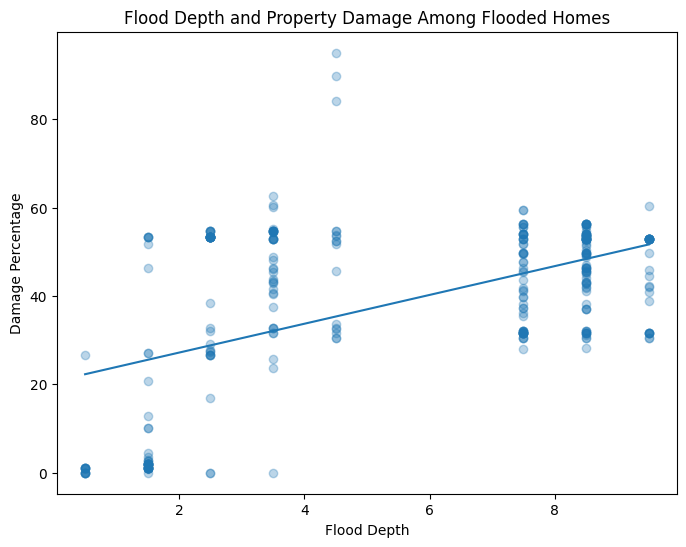

In [29]:
x_depth = flood_nonzero['FloodDepth'].values
y_damage = flood_nonzero['Percentage'].values

slope_depth, intercept_depth = np.polyfit(x_depth, y_damage, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_depth, y_damage, alpha=0.30)
plt.plot(np.sort(x_depth), slope_depth * np.sort(x_depth) + intercept_depth)
plt.xlabel("Flood Depth")
plt.ylabel("Damage Percentage")
plt.title("Flood Depth and Property Damage Among Flooded Homes")
plt.show()

**Cell 19**

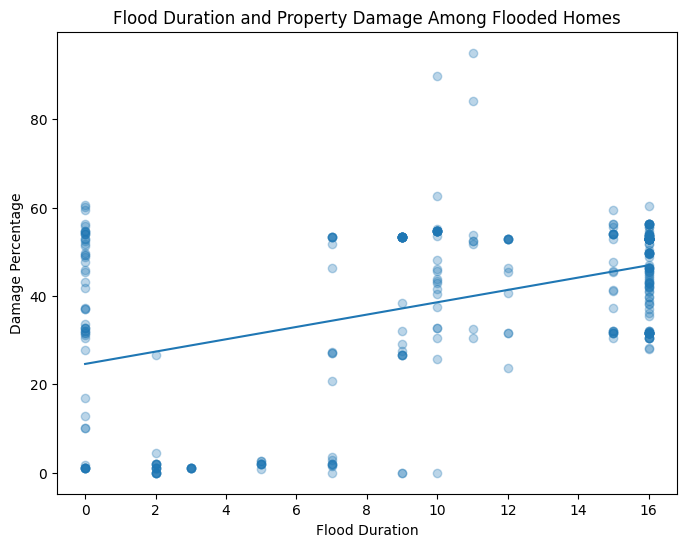

In [30]:
x_duration = flood_nonzero['FloodDuration'].values
y_damage = flood_nonzero['Percentage'].values

slope_duration, intercept_duration = np.polyfit(x_duration, y_damage, 1)

plt.figure(figsize=(8, 6))
plt.scatter(x_duration, y_damage, alpha=0.30)
plt.plot(np.sort(x_duration), slope_duration * np.sort(x_duration) + intercept_duration)
plt.xlabel("Flood Duration")
plt.ylabel("Damage Percentage")
plt.title("Flood Duration and Property Damage Among Flooded Homes")
plt.show()

**Cell 20**

In [31]:
depth_damage_summary_q3 = (
    flood_nonzero.groupby('FloodDepth', as_index=False)['Percentage']
    .mean()
    .sort_values('FloodDepth')
)

print(depth_damage_summary_q3)

   FloodDepth  Percentage
0         0.5    2.491429
1         1.5   10.010833
2         2.5   42.991538
3         3.5   46.099524
4         4.5   51.728824
5         7.5   42.996452
6         8.5   47.589783
7         9.5   45.622500


**Cell 21**

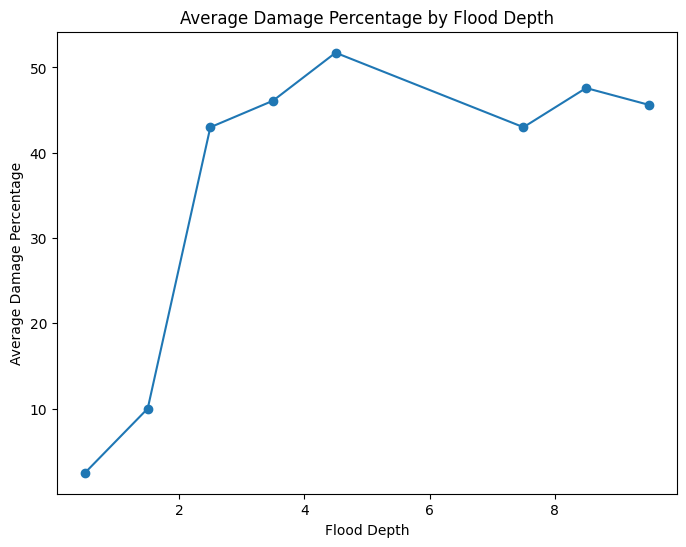

In [32]:
plt.figure(figsize=(8, 6))
plt.plot(depth_damage_summary_q3['FloodDepth'], depth_damage_summary_q3['Percentage'], marker='o')
plt.xlabel("Flood Depth")
plt.ylabel("Average Damage Percentage")
plt.title("Average Damage Percentage by Flood Depth")
plt.show()

**Cell 22**

In [33]:
q3_hpi_summary = []

for state in gulf_states:
    state_data = annual_hpi[annual_hpi['state'] == state]
    pre = state_data[state_data['year'] < 2005]['hpi']
    post = state_data[state_data['year'] > 2005]['hpi']
    
    q3_hpi_summary.append({
        'state': state,
        'pre_mean_hpi': pre.mean(),
        'post_mean_hpi': post.mean(),
        'change_in_hpi': post.mean() - pre.mean()
    })

q3_hpi_summary = pd.DataFrame(q3_hpi_summary)
print(q3_hpi_summary)

  state  pre_mean_hpi  post_mean_hpi  change_in_hpi
0    LA    120.351500     276.738465     156.386965
1    MS    135.047833     277.802632     142.754798
2    AL    152.191083     331.436053     179.244969


**Cell 23**

In [34]:
q3_short_summary = []

for state in gulf_states:
    state_data = annual_hpi[annual_hpi['state'] == state]
    short_pre = state_data[(state_data['year'] >= 2002) & (state_data['year'] < 2005)]['hpi']
    short_post = state_data[(state_data['year'] > 2005) & (state_data['year'] <= 2008)]['hpi']
    
    q3_short_summary.append({
        'state': state,
        'short_pre_mean_hpi': short_pre.mean(),
        'short_post_mean_hpi': short_post.mean(),
        'short_change_in_hpi': short_post.mean() - short_pre.mean()
    })

q3_short_summary = pd.DataFrame(q3_short_summary)
print(q3_short_summary)

  state  short_pre_mean_hpi  short_post_mean_hpi  short_change_in_hpi
0    LA          186.755833           241.200833            54.445000
1    MS          205.424167           252.975000            47.550833
2    AL          238.008333           295.535000            57.526667


**Cell 24**

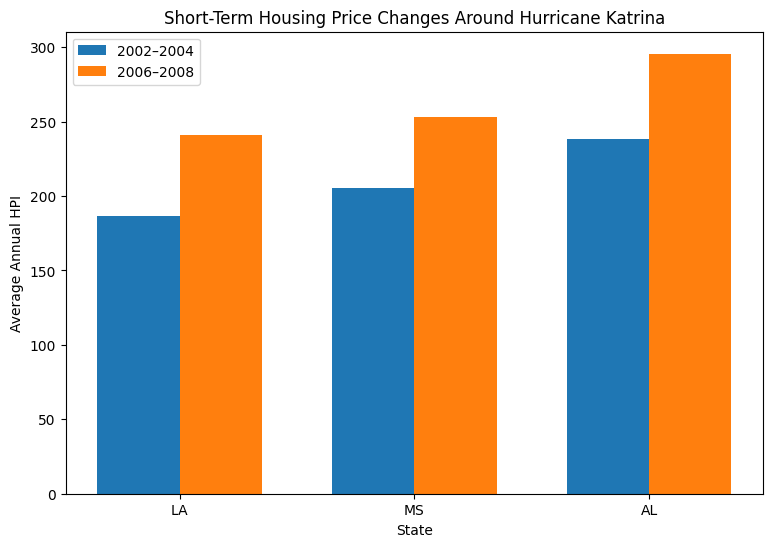

In [35]:
x = np.arange(len(q3_short_summary))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, q3_short_summary['short_pre_mean_hpi'], width, label='2002–2004')
plt.bar(x + width/2, q3_short_summary['short_post_mean_hpi'], width, label='2006–2008')

plt.xticks(x, q3_short_summary['state'])
plt.xlabel("State")
plt.ylabel("Average Annual HPI")
plt.title("Short-Term Housing Price Changes Around Hurricane Katrina")
plt.legend()
plt.show()

**Cell 25**

In [36]:
micro_macro_summary = pd.DataFrame({
    'metric': [
        'Total flood dataset rows',
        'Flooded-only usable rows',
        'Mean flood depth (flooded homes)',
        'Mean flood duration (flooded homes)',
        'Mean damage percentage (flooded homes)',
        'Flood depth slope on damage',
        'Flood depth R-squared',
        'Flood depth p-value',
        'Flood duration slope on damage',
        'Flood duration R-squared',
        'Flood duration p-value'
    ],
    'value': [
        flood.shape[0],
        flood_nonzero.shape[0],
        flood_nonzero['FloodDepth'].mean(),
        flood_nonzero['FloodDuration'].mean(),
        flood_nonzero['Percentage'].mean(),
        depth_result_q3.slope,
        depth_result_q3.rvalue**2,
        depth_result_q3.pvalue,
        duration_result_q3.slope,
        duration_result_q3.rvalue**2,
        duration_result_q3.pvalue
    ]
})

print(micro_macro_summary)

                                    metric         value
0                 Total flood dataset rows  1.655640e+05
1                 Flooded-only usable rows  3.460000e+02
2         Mean flood depth (flooded homes)  5.638728e+00
3      Mean flood duration (flooded homes)  1.034104e+01
4   Mean damage percentage (flooded homes)  3.905087e+01
5              Flood depth slope on damage  3.261894e+00
6                    Flood depth R-squared  2.753750e-01
7                      Flood depth p-value  7.073502e-26
8           Flood duration slope on damage  1.396127e+00
9                 Flood duration R-squared  1.979580e-01
10                  Flood duration p-value  3.176962e-18


**Cell 26**

In [37]:
q3_combined_summary = pd.merge(q3_hpi_summary, q3_short_summary, on='state', how='inner')
print(q3_combined_summary)

  state  pre_mean_hpi  post_mean_hpi  change_in_hpi  short_pre_mean_hpi  \
0    LA    120.351500     276.738465     156.386965          186.755833   
1    MS    135.047833     277.802632     142.754798          205.424167   
2    AL    152.191083     331.436053     179.244969          238.008333   

   short_post_mean_hpi  short_change_in_hpi  
0           241.200833            54.445000  
1           252.975000            47.550833  
2           295.535000            57.526667  


**Cell 27**

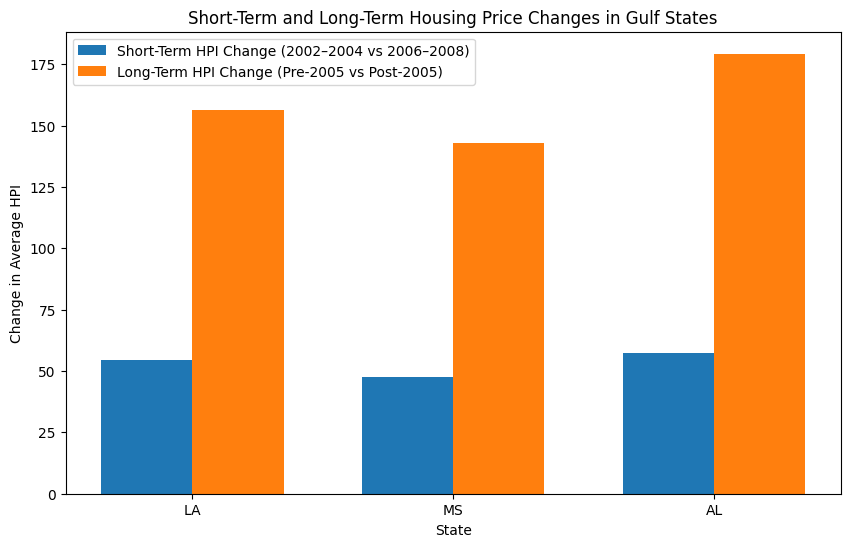

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

states = q3_combined_summary['state']
short_changes = q3_combined_summary['short_change_in_hpi']
long_changes = q3_combined_summary['change_in_hpi']

x = np.arange(len(states))
width = 0.35

ax.bar(x - width/2, short_changes, width, label='Short-Term HPI Change (2002–2004 vs 2006–2008)')
ax.bar(x + width/2, long_changes, width, label='Long-Term HPI Change (Pre-2005 vs Post-2005)')

ax.set_xticks(x)
ax.set_xticklabels(states)
ax.set_xlabel("State")
ax.set_ylabel("Change in Average HPI")
ax.set_title("Short-Term and Long-Term Housing Price Changes in Gulf States")
ax.legend()

plt.show()

**Cell 28**

In [39]:
print("QUESTION 3 METHODOLOGICAL CHECK")
print("- Flood dataset level: property-level observations")
print("- HPI dataset level: state-year observations")
print("- Direct row-level merge possible?: No")
print("- Multi-scale synthesis possible?: Yes")
print("- Interpretation should be causal?: No, only suggestive and comparative")

QUESTION 3 METHODOLOGICAL CHECK
- Flood dataset level: property-level observations
- HPI dataset level: state-year observations
- Direct row-level merge possible?: No
- Multi-scale synthesis possible?: Yes
- Interpretation should be causal?: No, only suggestive and comparative
